In [36]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))
from simu_PSF_polarMFM_JAX import *
from simu_PSF_polarMFM import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
device = torch.device('cuda')

In [37]:
N_photons=1000 # number of photons collected 
N=80 # discretization of the BFP
l_pixel=16 #pixel size in micrometer
NA=1.4 # numerical aperture
mag=100 # first magnification
lambd=617 # wavelength
f_tube=200 # tube lens focal
MAG=200/150 # second magnification

In [38]:
x, y, th1, phi, (Ex0, Ex1, Ex2), (Ey0, Ey1, Ey2), r, r_cut, k, f_o = vectorial_BFP_perfect_focus_jax(N, NA, mag, lambd, f_tube)

In [39]:
zernike_base = generate_zernike_base_jax(r_cut, N, zernike_order=4, device=device)

In [40]:
u, v, Npadding = padding_jax(r, r_cut, k, f_o)
print(Npadding)

74


In [41]:
xp = jnp.array([0.3,0.,0.,0.,0.])
yp = jnp.array([0.,0.,0.,0.,0.])
zp = jnp.array([3.*0.617,1.,1.,1.,1.])
d = -3.6*0.617/0.8+0.35
second_plane = jnp.array([0.3, 0, -0.3])
polar_projections = jnp.array([0., 45., 0.])

In [42]:
th1 = pad_jax(th1, Npadding)
phi = pad_jax(phi, Npadding)
Ex0 = pad_jax(Ex0, Npadding)
Ex1 = pad_jax(Ex1, Npadding)
Ex2 = pad_jax(Ex2, Npadding)
Ey0 = pad_jax(Ey0, Npadding)
Ey1 = pad_jax(Ey1, Npadding)
Ey2 = pad_jax(Ey2, Npadding)
zernike_base = pad_jax(zernike_base, Npadding)

In [43]:
zernike_base.shape

(15, 154, 154)

In [44]:
Mj = compute_M_jax(xp, yp, zp, d, x, y, th1, phi, Ex0, Ex1, Ex2, Ey0, Ey1, Ey2, u, v, zernike_base, jnp.zeros((3,15)), jnp.zeros((3,15)),  second_plane=second_plane
                  , polar_projections=polar_projections)

In [52]:
rho = jnp.array([45.,30.,40.,80.,100.])
eta = jnp.array([45.,60.,30.,80.,50.])
delta = jnp.array([50.,100.,100.,100.,100.])
N_photons = jnp.array([1000.,1000.,1000.,1000.,1000.])

In [53]:
psf_jax = PSF_jax(rho, eta, delta, Mj, N_photons)

(70.0, 85.0)

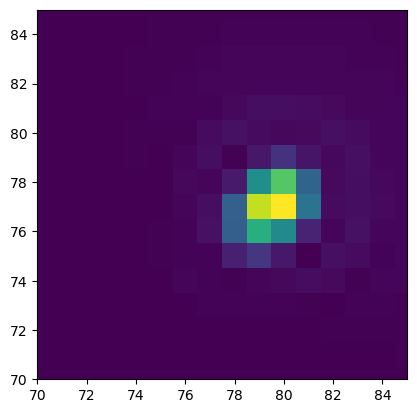

In [54]:
plt.imshow(psf_jax[0,1,0])
plt.xlim((70,85))
plt.ylim((70,85))

In [48]:
psf_jax.shape

(5, 3, 2, 154, 154)

In [49]:
Mj.shape

(5, 3, 2, 3, 3, 154, 154)

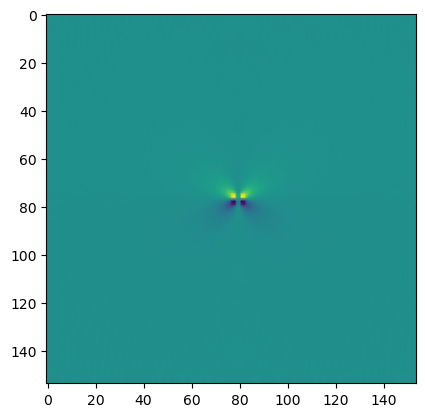

In [51]:
plt.imshow(jnp.real(Mj[0,0,0,1,2]))

In [59]:
key = jax.random.PRNGKey(0)

In [62]:
psf_noise_jax = noise_jax(key, psf_jax, QE=0.95, EM=200, b=5.0, sigma_b=0.1, sigma_r=1.0, bias=5.0)

(70.0, 85.0)

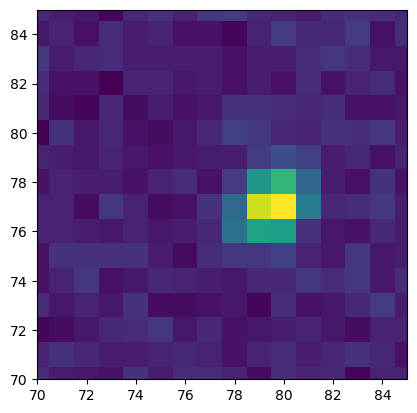

In [63]:
plt.imshow(psf_noise_jax[0,1,0])
plt.xlim((70,85))
plt.ylim((70,85))